# Predicting Benzene (C6H6) from Air Quality Sensors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

TARGET = "C6H6(GT)"

## Step 1: Convert -200 to NaN

In [2]:
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
df = df.dropna(how="all").dropna(how="all", axis=1)
df = df.replace(-200, np.nan)

print("Missing rate per column (%):")
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))

Missing rate per column (%):
NMHC(GT)         90.2
CO(GT)           18.0
NOx(GT)          17.5
NO2(GT)          17.5
PT08.S2(NMHC)     3.9
C6H6(GT)          3.9
PT08.S1(CO)       3.9
PT08.S5(O3)       3.9
T                 3.9
PT08.S3(NOx)      3.9
PT08.S4(NO2)      3.9
RH                3.9
AH                3.9
Date              0.0
Time              0.0
dtype: float64


## Step 2: Drop NMHC(GT) and rows with missing target

In [3]:
df = df.drop(columns=["NMHC(GT)"])      # about 90% missing
df = df.dropna(subset=[TARGET])

df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H.%M.%S")
df = df.sort_values("Datetime").reset_index(drop=True)

y = df[TARGET].values
X = df.drop(columns=[TARGET])

## Step 3: Chronological train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Train period: {X_train['Datetime'].min()} - {X_train['Datetime'].max()}, Shape: {X_train.shape}")
print(f"Test period: {X_test['Datetime'].min()} - {X_test['Datetime'].max()}, Shape: {X_test.shape}")

Train period: 2004-03-10 18:00:00 - 2005-01-16 01:00:00, Shape: (7192, 14)
Test period: 2005-01-16 02:00:00 - 2005-04-04 14:00:00, Shape: (1799, 14)


## Step 4: Temporal feature engineering
Hour and day of week as sine/cosine pairs, so 23:00 and 00:00 are close together.

In [5]:
def add_time_features(data):
    data = data.copy()
    hour = data["Datetime"].dt.hour
    weekday = data["Datetime"].dt.dayofweek
    data["Hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["Hour_cos"] = np.cos(2 * np.pi * hour / 24)
    data["Weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
    data["Weekday_cos"] = np.cos(2 * np.pi * weekday / 7)
    return data.drop(columns=["Date", "Time", "Datetime"])

X_train = add_time_features(X_train)
X_test = add_time_features(X_test)

time_cols = ["Hour_sin", "Hour_cos", "Weekday_sin", "Weekday_cos"]
sensor_cols = [c for c in X_train.columns if c not in time_cols]
log_cols = [c for c in sensor_cols if X_train[c].min() >= 0]    # log1p needs non-negative values

## Step 5: Median imputation

The preprocessing pipeline below runs, in order: median imputation, optional log/power transform, standardisation (step 7). Everything is fitted on the training data only.

In [6]:
def pick(names):
    # lets the pipeline still work if some columns are removed later
    return lambda data: [c for c in names if c in data.columns]

def make_preprocessor(feature_transform):
    if feature_transform == "log1p":
        transform, columns = FunctionTransformer(np.log1p, feature_names_out="one-to-one"), log_cols
    elif feature_transform == "yeo-johnson":
        transform, columns = PowerTransformer(standardize=False), sensor_cols
    else:
        transform, columns = "passthrough", sensor_cols

    return make_pipeline(
        SimpleImputer(strategy="median"),
        ColumnTransformer([("transform", transform, pick(columns))],
                          remainder="passthrough", verbose_feature_names_out=False),
        StandardScaler(),
    ).set_output(transform="pandas")

## Step 6: Log / power transformation evaluation
First the skewness of the target, then a cross-validated comparison of every feature/target transform combination.

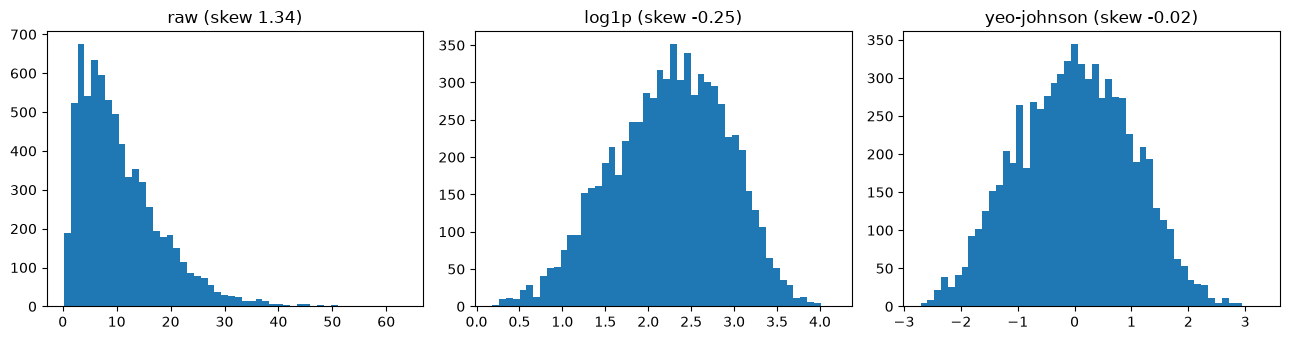

In [7]:
target_versions = {
    "raw": y_train,
    "log1p": np.log1p(y_train),
    "yeo-johnson": PowerTransformer().fit_transform(y_train.reshape(-1, 1)).ravel(),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, values) in zip(axes, target_versions.items()):
    ax.hist(values, bins=50)
    ax.set_title(f"{name} (skew {pd.Series(values).skew():.2f})")
plt.tight_layout()
plt.show()

In [8]:
target_transformers = {
    "none": None,
    "log1p": FunctionTransformer(np.log1p, inverse_func=np.expm1),
    "yeo-johnson": PowerTransformer(),
}

def get_models():
    return {
        "OLS": LinearRegression(),
        "Ridge": RidgeCV(alphas=np.logspace(-2, 3, 50), cv=TimeSeriesSplit(5)),
        "SVR": SVR(kernel="rbf", C=10, epsilon=0.1),
    }

def make_model(model, feature_transform, target_transform):
    # predictions are converted back to µg/m³ automatically
    return TransformedTargetRegressor(
        regressor=make_pipeline(make_preprocessor(feature_transform), model),
        transformer=target_transformers[target_transform],
    )

def cv_rmse(estimator, X_data, y_data):
    scores = cross_val_score(estimator, X_data, y_data, cv=TimeSeriesSplit(5),
                             scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [16]:
rows = []
for feature_transform in ["none", "log1p", "yeo-johnson"]:
    for target_transform in ["none", "log1p", "yeo-johnson"]:
        for model_name, model in get_models().items():
            rmse = cv_rmse(make_model(model, feature_transform, target_transform), X_train, y_train)
            rows.append([feature_transform, target_transform, model_name, rmse])

cv_results = pd.DataFrame(rows, columns=["features", "target", "model", "rmse"])
cv_table = cv_results.pivot_table(index=["features", "target"], columns="model", values="rmse")
cv_table["mean"] = cv_table.mean(axis=1)

print("Time-series CV RMSE in µg/m³ (lower is better):")
print(cv_table.sort_values("mean").round(4))

best_feature_tf, best_target_tf = cv_table["mean"].idxmin()
print("\nChosen:", best_feature_tf, "features,", best_target_tf, "target")

Time-series CV RMSE in µg/m³ (lower is better):
model                       OLS   Ridge     SVR    mean
features    target                                     
yeo-johnson yeo-johnson  0.0943  0.0941  1.9531  0.7139
log1p       yeo-johnson  0.4646  0.4647  1.9338  0.9544
            log1p        0.6664  0.6645  2.3924  1.2411
none        none         1.4284  1.4218  1.8620  1.5707
            yeo-johnson  1.4392  1.4031  2.4487  1.7636
yeo-johnson log1p        1.4702  1.4597  2.4127  1.7809
            none         2.5500  2.5253  1.3667  2.1473
log1p       none         3.0302  2.8173  1.3527  2.4001
none        log1p        2.6864  2.5121  2.8330  2.6772

Chosen: yeo-johnson features, yeo-johnson target


## Step 7: Standardisation
Using the chosen transform, fitted on the training set. VIF and Ridge in step 8 work on these standardised features.

In [10]:
X_train_std = make_preprocessor(best_feature_tf).fit_transform(X_train)
print("Max column mean:", X_train_std.mean().abs().max().round(6))
print("Column std     :", X_train_std.std(ddof=0).round(2).unique())

Max column mean: 0.0
Column std     : [1.]


## Step 8: VIF / Ridge feature selection

VIF shows how much a feature is explained by the others. The feature with the highest VIF is removed until all are 10 or below. Ridge coefficients show how much each feature contributes. The final choice between all features and the VIF-reduced set is made by cross-validation.

In [11]:
def vif_table(data):
    values = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return pd.Series(values, index=data.columns).sort_values(ascending=False)

print(vif_table(X_train_std).round(2))

kept = list(X_train_std.columns)
while True:
    vif = vif_table(X_train_std[kept])
    if vif.max() <= 10:
        break
    kept.remove(vif.idxmax())

print("\nDropped by VIF:", [c for c in X_train_std.columns if c not in kept])

PT08.S2(NMHC)    28.63
T                23.21
RH               15.75
AH               14.61
PT08.S5(O3)      11.79
PT08.S4(NO2)     11.30
PT08.S1(CO)       9.77
PT08.S3(NOx)      9.22
NOx(GT)           8.19
NO2(GT)           5.39
CO(GT)            4.68
Hour_sin          2.31
Hour_cos          1.70
Weekday_sin       1.08
Weekday_cos       1.05
dtype: float64

Dropped by VIF: ['PT08.S2(NMHC)', 'T']


Chosen alpha: 0.1048
PT08.S2(NMHC)    1.0054
PT08.S4(NO2)    -0.0068
PT08.S3(NOx)     0.0032
PT08.S1(CO)      0.0030
AH               0.0026
NOx(GT)         -0.0017
CO(GT)           0.0014
RH              -0.0010
PT08.S5(O3)     -0.0007
T                0.0004
Hour_cos        -0.0003
Weekday_cos     -0.0001
Hour_sin         0.0001
NO2(GT)         -0.0001
Weekday_sin      0.0000
dtype: float64


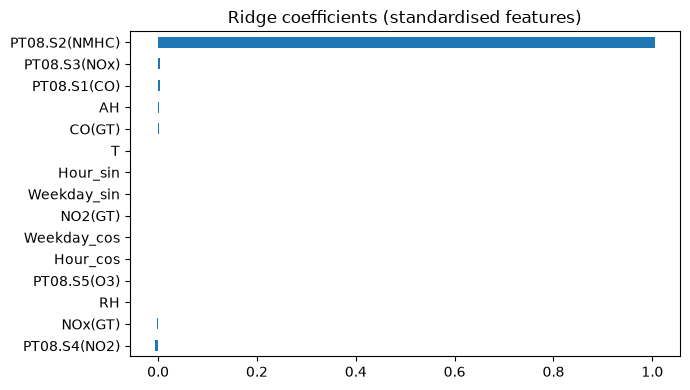

In [17]:
ridge = make_model(RidgeCV(alphas=np.logspace(-2, 3, 50), cv=TimeSeriesSplit(5)),
                   best_feature_tf, best_target_tf).fit(X_train, y_train)
ridge_coefs = pd.Series(ridge.regressor_[-1].coef_, index=X_train_std.columns)

print("Chosen alpha:", round(ridge.regressor_[-1].alpha_, 4))
print(ridge_coefs.reindex(ridge_coefs.abs().sort_values(ascending=False).index).round(4))

ridge_coefs.sort_values().plot.barh(figsize=(7, 4), title="Ridge coefficients (standardised features)")
plt.tight_layout()
plt.show()

In [13]:
feature_sets = {"all features": list(X_train.columns), "VIF-reduced": kept}

set_scores = {}
for set_name, cols in feature_sets.items():
    set_scores[set_name] = np.mean([
        cv_rmse(make_model(model, best_feature_tf, best_target_tf), X_train[cols], y_train)
        for model in get_models().values()
    ])
print(pd.Series(set_scores).round(4))

best_set = min(set_scores, key=set_scores.get)
final_cols = feature_sets[best_set]
print("\nChosen:", best_set, f"({len(final_cols)} features)")

all features    0.7139
VIF-reduced     2.1773
dtype: float64

Chosen: all features (15 features)


## Step 9: Model training and evaluation
Trained on the training set, scored once on the test set. All errors are in µg/m³.

In [14]:
def test_scores(X_tr, X_te):
    rows = []
    for name, model in get_models().items():
        fitted = make_model(model, best_feature_tf, best_target_tf).fit(X_tr, y_train)
        pred = fitted.predict(X_te)
        rows.append({"Model": name,
                     "MAE": mean_absolute_error(y_test, pred),
                     "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                     "R2": r2_score(y_test, pred)})
    return pd.DataFrame(rows).round(4)

results = test_scores(X_train[final_cols], X_test[final_cols])
print(results.to_string(index=False))

Model    MAE   RMSE     R2
  OLS 0.0406 0.0573 0.9999
Ridge 0.0405 0.0572 0.9999
  SVR 0.6236 0.8380 0.9835


## Step 10: Checking the dominant sensor
The Ridge coefficients in step 8 are dominated by one sensor. These checks show whether the accuracy is genuine and what happens without it.

In [15]:
S2 = "PT08.S2(NMHC)"

# 1. a model trained on a shuffled target should score about 0 (no leakage)
shuffled_y = np.random.default_rng(0).permutation(y_train)
shuffled_model = make_model(LinearRegression(), best_feature_tf, best_target_tf).fit(X_train, shuffled_y)
print("R2 with shuffled target:", round(r2_score(y_test, shuffled_model.predict(X_test)), 4))

# 2. the sensor on its own
only_s2 = make_model(LinearRegression(), best_feature_tf, best_target_tf).fit(X_train[[S2]], y_train)
print("R2 using only", S2 + ":", round(r2_score(y_test, only_s2.predict(X_test[[S2]])), 4))

# 3. all models without the sensor (same transforms as before)
without_s2 = test_scores(X_train.drop(columns=S2), X_test.drop(columns=S2))
comparison = pd.concat([results.assign(Features="with " + S2), without_s2.assign(Features="without " + S2)])
print()
print(comparison[["Features", "Model", "MAE", "RMSE", "R2"]].to_string(index=False))

R2 with shuffled target: -0.0764
R2 using only PT08.S2(NMHC): 0.9999

             Features Model    MAE   RMSE     R2
   with PT08.S2(NMHC)   OLS 0.0406 0.0573 0.9999
   with PT08.S2(NMHC) Ridge 0.0405 0.0572 0.9999
   with PT08.S2(NMHC)   SVR 0.6236 0.8380 0.9835
without PT08.S2(NMHC)   OLS 1.3378 2.0585 0.9002
without PT08.S2(NMHC) Ridge 1.3739 2.0799 0.8981
without PT08.S2(NMHC)   SVR 1.3638 1.7999 0.9237
